In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Logic**:

*Long Only*
1. On daily basis, choose stocks within top 20% sentiment score
2. Get sum of weighted returns of the stock.
3. Repeat Steps 1 and 2 for the next day.

*Short Only*
1. On daily basis, choose stocks within bottom 20% sentiment score
2. Get sum of weighted returns of the stock.
3. Repeat Steps 1 and 2 for the next day.

Notes:
- Download 500 stock prices in single dataframe from yfinance
- Each day, store the list of stocks to pick in a separate dict {date: list of stocks}
- Get portfolio daily returns (pct_change().shift(-1) for selected stocks and take average)

In [2]:
import requests
response = requests.get('https://stockanalysis.com/list/sp-500-stocks/')
companies_info_df = pd.read_html(response.content)[0]
companies_info_df = companies_info_df.drop(columns=["No.", "Stock Price", "% Change", "Revenue"])
sp500_tickers = companies_info_df["Symbol"].to_list()

In [3]:
import yfinance as yf
stocks = yf.download(sp500_tickers, threads=True, group_by='ticker', start='2024-01-01', end='2024-12-16', multi_level_index=False)

[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['BRK.B']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
['BF.B']: YFPricesMissingError('$%ticker%: possibly delisted; no price data found  (1d 2024-01-01 -> 2024-12-16)')


In [4]:
stocks.index = (
    stocks.index
    .tz_localize("EST")
    .tz_convert("UTC")
    .tz_localize(None)
    .normalize()
)

In [5]:
stocks = stocks.xs('Adj Close', axis=1, level=1, drop_level=True)

In [6]:
def pick_stocks(sentiment_df, long_short='long', percentile=0.2):

    if long_short =='long':
        top_tickers_dict = (
            sentiment_df.groupby(['date', 'ticker'])['score'].mean()
            .reset_index()
            .sort_values(['date', 'score'], ascending=[True, False])
            .groupby('date')
            .apply(lambda group: group['ticker'].head(max(1, int(len(group) * percentile))).tolist())
            .to_dict()
        )
        
    elif long_short == 'short':
            top_tickers_dict = (
            sentiment_df.groupby(['date', 'ticker'])['score'].mean()
            .reset_index()
            .sort_values(['date', 'score'], ascending=[True, True])
            .groupby('date')
            .apply(lambda group: group['ticker'].head(max(1, int(len(group) * percentile))).tolist())
            .to_dict()
        )
    return top_tickers_dict


In [7]:
class Portfolio:
    def __init__(self, price_df, long_short=None, long_tickers_dict=None, short_tickers_dict=None, capital=100000, trading_cost=0.001):
        self.price_df = price_df
        self.long_short = long_short
        self.long_tickers_dict = long_tickers_dict
        self.short_tickers_dict = short_tickers_dict
        self.initial_capital = capital
        self.trading_cost = trading_cost
        self.portfolio_returns = None
        self.portfolio_value = None
        self.all_stocks = price_df.columns.to_list()
        self.selected_long_stocks = np.zeros(len(price_df.columns.to_list()))
        self.selected_short_stocks = np.zeros(len(price_df.columns.to_list()))
        self.selected_stocks = np.zeros(len(price_df.columns.to_list()))
        self.capital= capital
        self.previous_tickers = []
        self.previous_short_tickers = []
        self.previous_long_tickers = []
        
    def calculate_portfolio_returns(self):
        portfolio_value = {}
        returns_df = self.price_df.pct_change().shift(-1).copy()
        self.returns_df = returns_df
        returns_df = returns_df.dropna(how = 'all').copy()
        if self.long_short is None:
            print('No strategy selected!')
            return None
        
        if self.long_tickers_dict is None and self.short_tickers_dict is None:
            print('No stocks selected!')
            return None

        elif self.long_short == 'Long' and self.long_tickers_dict:
            for idx in returns_df.index:
                
                # identify top X percentile of positive sentiment stocks for the day
                if idx in self.long_tickers_dict:
                    tickers = self.long_tickers_dict[idx]
                    # store current stock picks for comparison with next day
                    self.previous_tickers = tickers 
                else:
                    # use previous stock picks if no news available for current day
                    tickers = self.previous_tickers 

                # Get index of newly selected stocks for current day
                new_selected_stocks = np.isin(self.all_stocks, tickers).astype(int)
                
                if tickers == []:
                    weight_changes = 0
                else:
                    # Compare number of stocks bought and sold as a proportion of total stocks selected
                    weight_changes = abs(new_selected_stocks - self.selected_stocks).sum()/len(tickers)
                
                if returns_df.loc[idx][tickers].empty: # if no stock in portfolio let portfolio value be the capital
                    portfolio_value[idx] = self.capital + 0 * self.capital - weight_changes * self.capital * self.trading_cost
                else:
                    portfolio_value[idx] = self.capital + returns_df.loc[idx][tickers].mean() * self.capital - weight_changes * self.capital * self.trading_cost
                
                # Update Portfolio value for the day
                self.capital = portfolio_value[idx]
                # Update boolean array of selected_stocks
                self.selected_stocks = new_selected_stocks

        elif self.long_short == 'Short' and self.short_tickers_dict:
            for idx in returns_df.index:
                # identify top X percentile of negative sentiment stocks for the day
                if idx in self.short_tickers_dict:
                    tickers = self.short_tickers_dict[idx]
                    # store current stock picks for comparison with next day
                    self.previous_tickers = tickers
                else:
                    # use previous stock picks if no news available for current day
                    tickers = self.previous_tickers
                
                # Get index of newly selected stocks for current day
                new_selected_stocks = np.isin(self.all_stocks, tickers).astype(int)
                
                if tickers == []:
                    weight_changes = 0
                else:
                    # Compare number of stocks bought and sold as a proportion of total stocks selected
                    weight_changes = abs(new_selected_stocks - self.selected_stocks).sum()/len(tickers)
                
                if returns_df.loc[idx][tickers].empty: # if no stock in portfolio let portfolio value be the capital
                    portfolio_value[idx] = self.capital + 0 * self.capital - weight_changes * self.capital * self.trading_cost
                else:
                    portfolio_value[idx] = self.capital + -returns_df.loc[idx][tickers].mean() * self.capital - weight_changes * self.capital * self.trading_cost

                
                # Update Portfolio value for the day
                self.capital = portfolio_value[idx]
                # Update boolean array of selected_stocks
                self.selected_stocks = new_selected_stocks

        elif self.long_short == 'Long_Short' and self.short_tickers_dict and self.long_tickers_dict:
            for idx in returns_df.index:
                # identify top X percentile of negative sentiment stocks for the day
                if idx in self.short_tickers_dict:
                    short_tickers = self.short_tickers_dict[idx]
                    self.previous_short_tickers = short_tickers
                else:
                    short_tickers = self.previous_short_tickers

                # identify top X percentile of positive sentiment stocks for the day
                if idx in self.long_tickers_dict:
                    long_tickers = self.long_tickers_dict[idx]
                    self.previous_long_tickers = long_tickers
                else:
                    long_tickers = self.previous_long_tickers

                # Get index of newly selected stocks for current day
                new_selected_long_stocks = np.isin(self.all_stocks, long_tickers).astype(int)
                new_selected_short_stocks = np.isin(self.all_stocks, short_tickers).astype(int)

                if short_tickers == [] or long_tickers == []:
                    weight_changes = 0

                else:
                    long_weight_changes = abs(new_selected_long_stocks - self.selected_long_stocks).sum()/len(long_tickers + short_tickers)
                    short_weight_changes = abs(new_selected_short_stocks - self.selected_short_stocks).sum()/len(long_tickers + short_tickers)
                    weight_changes = long_weight_changes + short_weight_changes

                if returns_df.loc[idx][long_tickers].empty or returns_df.loc[idx][short_tickers].empty:
                    portfolio_value[idx] = self.capital + 0 - weight_changes * self.capital * self.trading_cost
                else:    
                    portfolio_value[idx] = self.capital + ((returns_df.loc[idx][long_tickers].sum() - returns_df.loc[idx][short_tickers].sum()) / len(long_tickers + short_tickers))\
                    * self.capital - weight_changes * self.capital * self.trading_cost

                self.capital = portfolio_value[idx]
                self.selected_long_stocks = new_selected_long_stocks
                self.selected_short_stocks = new_selected_short_stocks

                
        else:
            print('Error or combination not correct')
            return None
        
        # Convert portfolio returns to DataFrame
        self.portfolio_value = pd.DataFrame(list(portfolio_value.items()), columns=['Date', 'Portfolio_value']).fillna(0)
        
        self.portfolio_returns = self.portfolio_value.copy()
        self.portfolio_returns['Portfolio_returns'] = self.portfolio_returns['Portfolio_value'].pct_change()

        # Calculate cumulative returns
        self.portfolio_returns['Cumulative_returns'] = (1 + self.portfolio_returns['Portfolio_returns']).cumprod() - 1
        
        return self.portfolio_returns
    
    def calculate_sharpe_ratio(self, risk_free_rate=0.0):
        if self.portfolio_returns is None:
            print("Portfolio returns are not calculated. Please calculate returns first.")
            return None
        
        # Calculate average daily return and daily standard deviation
        avg_daily_return = self.portfolio_returns['Portfolio_returns'].mean()
        daily_std_dev = self.portfolio_returns['Portfolio_returns'].std()
        
        # Annualize the return and standard deviation
        annualized_return = avg_daily_return * 252  # 252 trading days in a year
        annualized_std_dev = daily_std_dev * np.sqrt(252)
        
        # Calculate annualized Sharpe ratio
        sharpe_ratio = (annualized_return - risk_free_rate) / annualized_std_dev
        return sharpe_ratio
    
    def plot_cumulative_returns(self):
        if self.portfolio_returns is None:
            print("Portfolio returns are not calculated. Please calculate returns first.")
            return None
        
        # Calculate cumulative returns
        self.portfolio_returns['Cumulative_returns'] = (1 + self.portfolio_returns['Portfolio_returns']).cumprod() - 1
        
        # Plot cumulative returns
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8, 4))
        plt.plot(self.portfolio_returns['Date'], self.portfolio_returns['Cumulative_returns'], label='Cumulative Portfolio Returns')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Return')
        plt.title(f'Portfolio Cumulative Returns for {self.long_short} Strategy')
        plt.legend()
        plt.grid(True)
        plt.show()
    def plot_cumulative_value(self):
        if self.portfolio_value is None:
            print("Portfolio value are not calculated. Please calculate value first.")
            return None
        
        # Plot cumulative returns
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8, 4))
        plt.plot(self.portfolio_value['Date'], self.portfolio_value['Portfolio_value'], label='Cumulative Portfolio Value')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Value')
        plt.title(f'Portfolio Cumulative Value for {self.long_short} Strategy')
        plt.legend()
        plt.grid(True)
        plt.show()

    def calculate_total_return(self):
        """Calculate the total return of the strategy."""
        total_return = self.portfolio_returns['Cumulative_returns'].iloc[-1]
        return total_return
    

    def run_backtest(self):
        """Run the backtest and return key metrics."""
        self.calculate_portfolio_returns()
        sharpe_ratio = self.calculate_sharpe_ratio()
        total_return = self.calculate_total_return()
        
        print(f'Sharpe Ratio: {sharpe_ratio:.3f}, \nTotal Return: {total_return:.3%}')
        self.plot_cumulative_value()
        self.plot_cumulative_returns()
        
        

# NB

In [8]:
nb = pd.read_csv('./results/naive_bayes_results.csv')

In [9]:
nb2 = nb[['date', 'ticker','pred_prob_0']].copy()
nb2['date'] = pd.to_datetime(nb2['date'])
nb2['score'] = 1- nb2['pred_prob_0']
nb2.drop(columns='pred_prob_0', inplace=True)

In [10]:
nb_stock_dict_long_only = pick_stocks(nb2, 'long', 0.2)
# nb_stock_dict_long_only

nb_stock_dict_short_only = pick_stocks(nb2, 'short', 0.2)
# nb_stock_dict_short_only

Sharpe Ratio: 1.425, 
Total Return: 58.714%


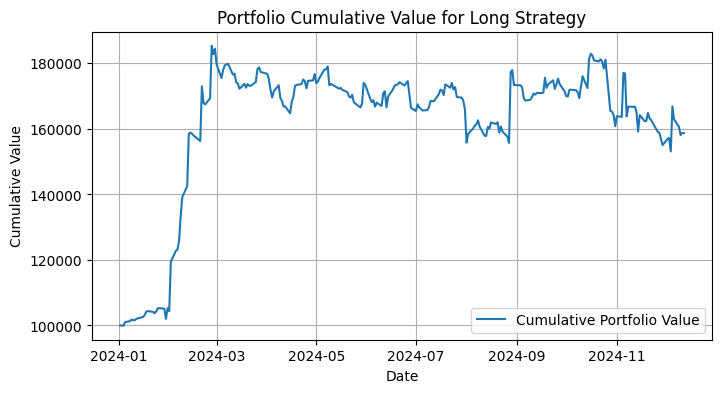

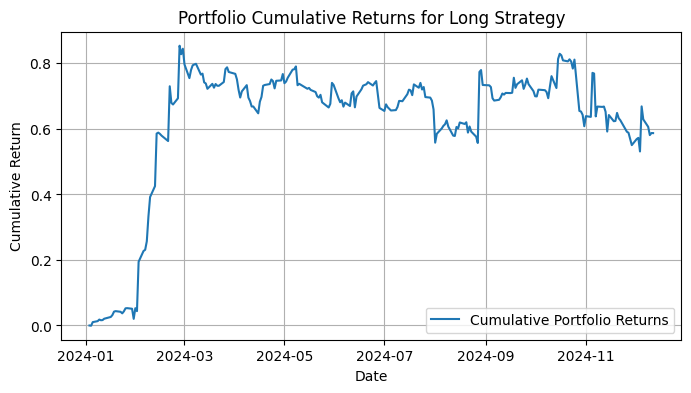

Sharpe Ratio: -3.347, 
Total Return: -72.650%


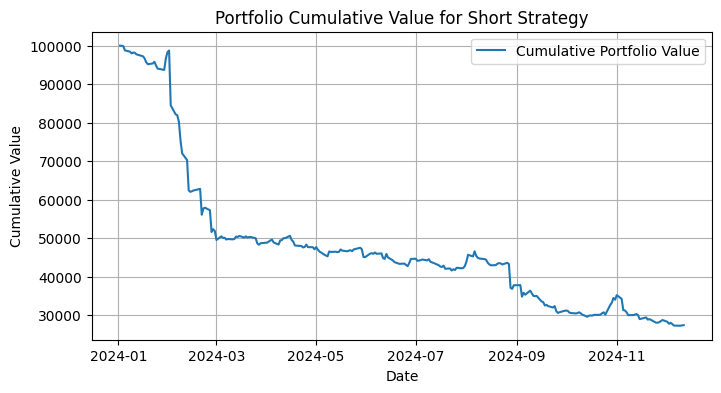

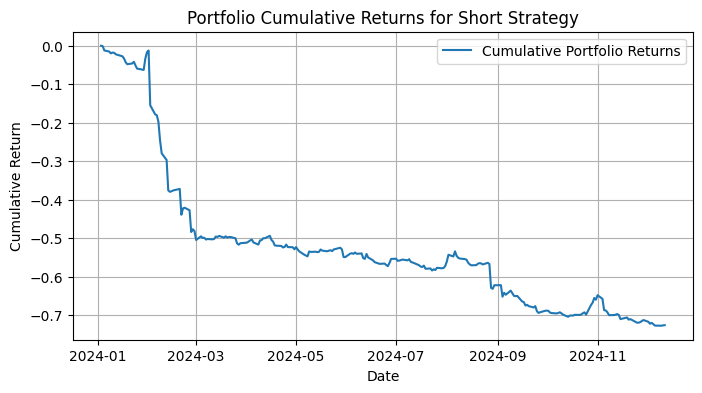

Sharpe Ratio: -2.874, 
Total Return: -29.603%


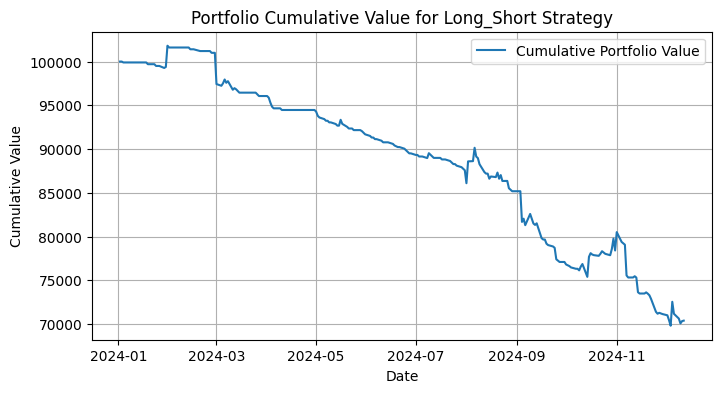

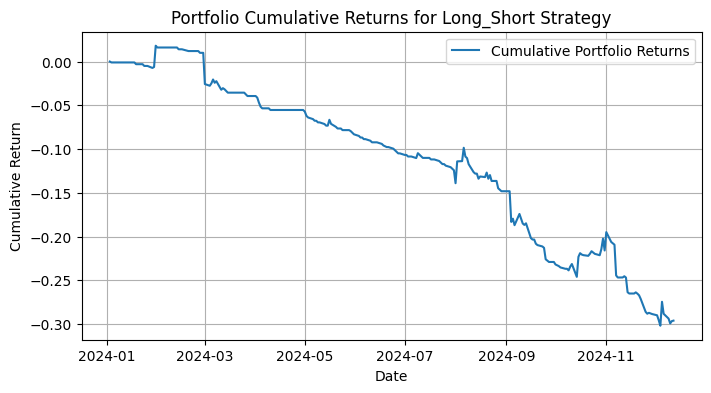

In [11]:
for strat in ['Long', 'Short', 'Long_Short']:
    nb_portfolio = Portfolio(stocks, strat, long_tickers_dict=nb_stock_dict_long_only, short_tickers_dict=nb_stock_dict_short_only, trading_cost=0.001)
    nb_portfolio.run_backtest()

# RNN

In [12]:
rnn = pd.read_csv('./results/rnn_results.csv')

In [13]:
rnn2 = rnn[['date', 'ticker','pred_prob_0']].copy()
rnn2['date'] = pd.to_datetime(rnn2['date'])
rnn2['score'] = 1- rnn2['pred_prob_0']
rnn2.drop(columns='pred_prob_0', inplace=True)

In [14]:
rnn_stock_dict_long_only = pick_stocks(rnn2, 'long', 0.2)
# nb_stock_dict_long_only

rnn_stock_dict_short_only = pick_stocks(rnn2, 'short', 0.2)
# nb_stock_dict_short_only

Sharpe Ratio: 1.787, 
Total Return: 83.205%


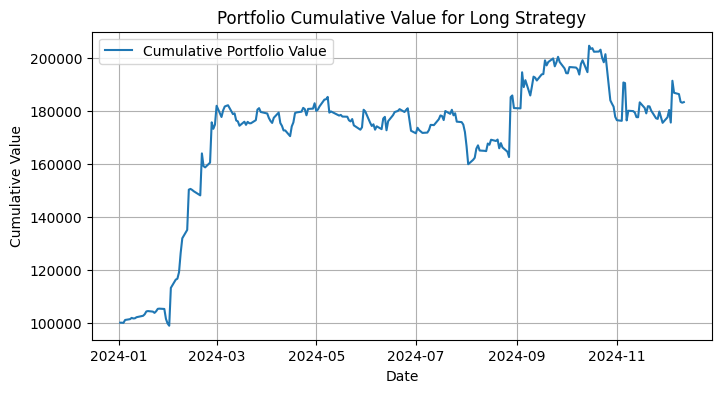

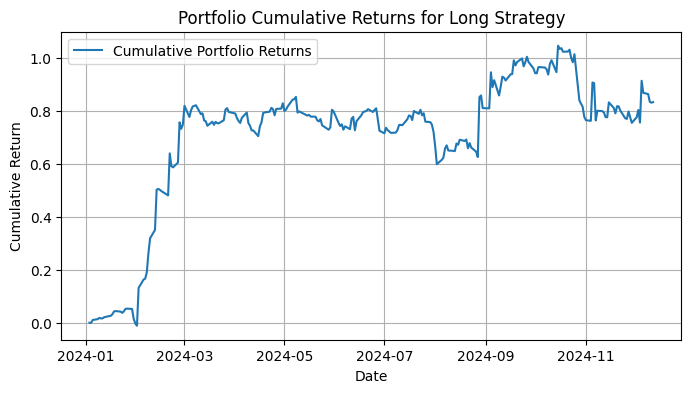

Sharpe Ratio: -2.936, 
Total Return: -67.061%


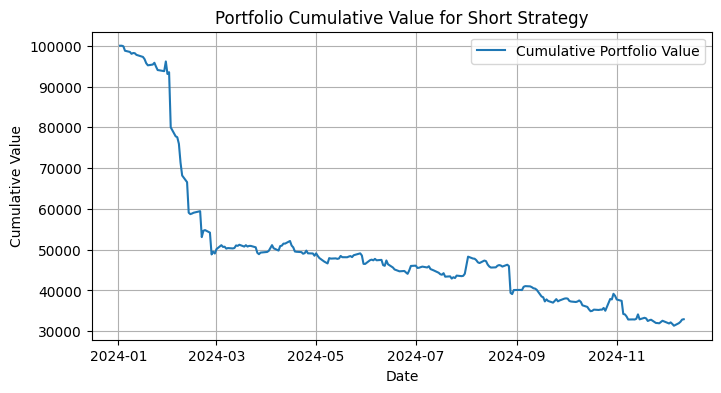

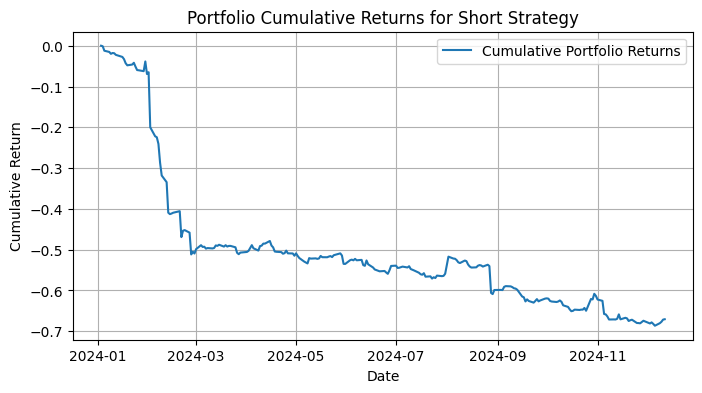

Sharpe Ratio: -1.727, 
Total Return: -16.938%


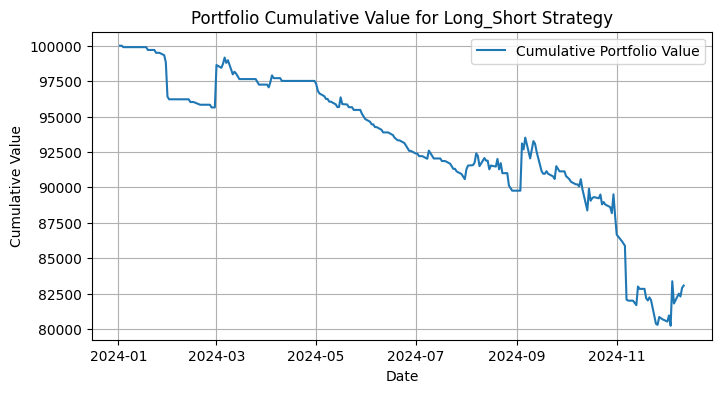

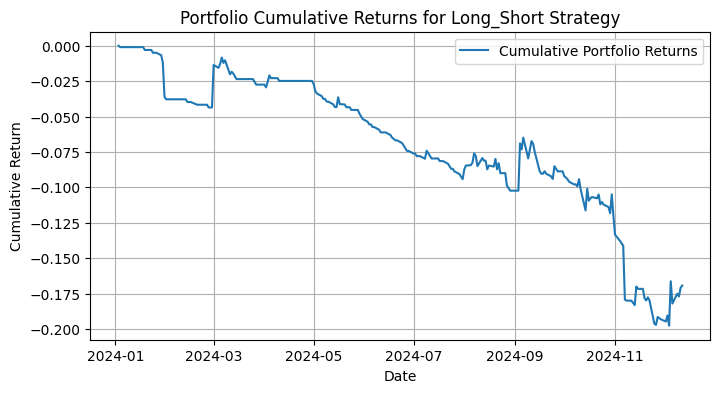

In [15]:
for strat in ['Long', 'Short', 'Long_Short']:
    rnn_portfolio = Portfolio(stocks, strat, long_tickers_dict=rnn_stock_dict_long_only, short_tickers_dict=rnn_stock_dict_short_only, trading_cost=0.001)
    rnn_portfolio.run_backtest()

# FinBert

In [17]:
finbert = pd.read_csv('./results/test_df_results_filtered.csv')
finbert['company name(s) - cleaned'] = finbert['company name(s) - cleaned'].apply(lambda x: x.strip() if isinstance(x, str) else x)

In [18]:
#Mapping using news_data_train & news_data_test
x= pd.read_csv('./Data/news_data_train.csv')
y = pd.read_csv('./Data/news_data_test.csv')
z = pd.concat([x,y])

mapping_df = z[['title','date','Ticker', 'source']].drop_duplicates()

In [19]:
finbert = finbert.merge(mapping_df, on=['title','date','source'], how='left')

In [20]:
finbert_no_missing = finbert[finbert.Ticker.notna()].copy()
finbert_missing = finbert[finbert.Ticker.isna()].copy()

In [21]:
# Mapping using SPY_companies_info
co_info = pd.read_csv('./Data/SPY_companies_info.csv')
co_info.rename(columns={'Company Name':'company name(s) - cleaned'}, inplace = True)
co_info = co_info[['company name(s) - cleaned', 'Symbol']].copy()

In [22]:
finbert_missing = finbert_missing.merge(co_info, how='left', on='company name(s) - cleaned')
finbert_missing['Ticker'] = np.where(finbert_missing['Symbol'].notna(), finbert_missing['Symbol'], finbert_missing['Ticker'])
finbert_missing.drop(columns='Symbol', inplace=True)

# Updating the non-missing and missing dataframe
finbert_no_missing = pd.concat([finbert_no_missing, finbert_missing[finbert_missing['Ticker'].notna()]])
finbert_missing = finbert_missing[finbert_missing['Ticker'].isna()].copy()

In [23]:
import re
def extract_ticker(text):
    match = re.search(r'\((\w+):(\w+)\)', text)  # Regex to find (XXXX: YYYY)
    if match:
        return match.group(2)  # Return YYYY
    else:
        return np.nan

In [24]:
# Mapping using ticker info in topic columns
finbert_missing['Ticker'] = finbert_missing['topic'].apply(lambda x: extract_ticker(str(x)))

In [25]:
# Updating the non-missing and missing dataframe
finbert_no_missing = pd.concat([finbert_no_missing, finbert_missing[finbert_missing['Ticker'].notna()]])
finbert_missing = finbert_missing[finbert_missing['Ticker'].isna()].copy()

In [26]:
finbert_missing = finbert_missing.merge(z[['source', 'Ticker']],on='source', how='left')
finbert_missing.drop(columns='Ticker_x', inplace=True)
finbert_missing.rename(columns={'Ticker_y':'Ticker'}, inplace=True)

In [27]:
finbert_no_missing = pd.concat([finbert_no_missing, finbert_missing])

In [28]:
finbert_no_missing

,title,source,topic,company name(s) - cleaned,date,sentiment_label,prob_negative,prob_neutral,prob_positive,finbert_sentiment_labels,Ticker
0,Visa Reimagines Customer Loyalty with New Web3...,Business Wire,Transaction and Payment Processing Services,Visa Inc.,2024-01-04,1,0.423700,0.021572,0.554728,1,V
1,True Potential Appoints Northern Trust for Ass...,Business Wire,Asset Management and Custody Banks,Northern Trust Corporation,2024-01-19,0,0.455273,0.023059,0.521668,1,NTRS
2,Wells Fargo & Company Approves and Adopts the ...,SEC Form 8k,Diversified Banks,Wells Fargo & Company,2024-01-24,1,0.507237,0.024754,0.468009,0,WFC
3,Abbott Laboratories Enters into Five Year Cred...,SEC Form 8k,Health Care Equipment,Abbott Laboratories,2024-01-29,1,0.788146,0.014926,0.196928,0,ABT
4,Leidos Wins Contract to Support Advanced Resea...,PR Newswire,Research and Consulting Services,"Leidos Holdings, Inc.",2024-01-29,0,0.437296,0.020836,0.541868,1,LDOS
...,...,...,...,...,...,...,...,...,...,...,...
1,"Essex Property Trust, Inc. Sees Significant Dr...",https://news.google.com/rss/articles/CBMirAFBV...,NaN,NaN,2024-12-03,0,0.644057,0.019660,0.336283,0,ESS
2,Corpay: Fairly Valued At Best - Seeking Alpha,https://news.google.com/rss/articles/CBMieEFVX...,NaN,NaN,2024-12-05,0,0.479499,0.023189,0.497312,1,CPAY
3,"Kinder Morgan, Inc. Shares Bought by MML Inves...",https://news.google.com/rss/articles/CBMiwAFBV...,NaN,NaN,2024-12-11,0,0.478957,0.046192,0.474851,0,KMI
4,"United Rentals, Inc. Shares Bought by American...",https://news.google.com/rss/articles/CBMisgFBV...,NaN,NaN,2024-12-13,0,0.454073,0.038049,0.507877,1,URI


In [29]:
fb2 = finbert_no_missing[['date', 'Ticker','prob_negative']].copy()
fb2['date'] = pd.to_datetime(fb2['date'])
fb2['score'] = 1- fb2['prob_negative']
fb2.drop(columns='prob_negative', inplace=True)
fb2.rename(columns={'Ticker':'ticker'},inplace=True)

In [30]:
fb2 = fb2[fb2['ticker'].isin(sp500_tickers)].copy()

In [31]:
fb_stock_dict_long_only = pick_stocks(fb2, 'long', 0.2)
# nb_stock_dict_long_only

fb_stock_dict_short_only = pick_stocks(fb2, 'short', 0.2)
# nb_stock_dict_short_only

Sharpe Ratio: 1.414, 
Total Return: 56.514%


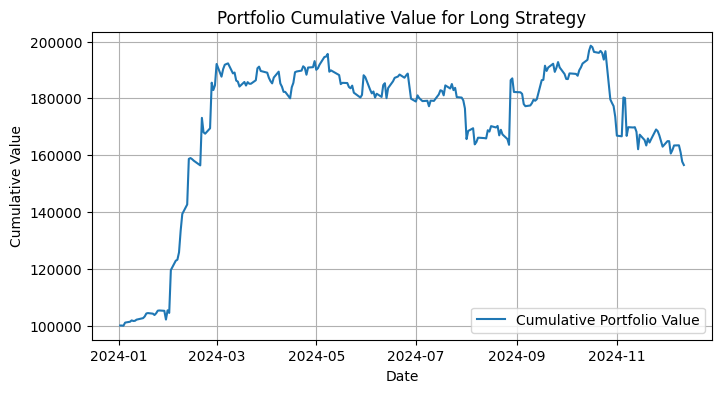

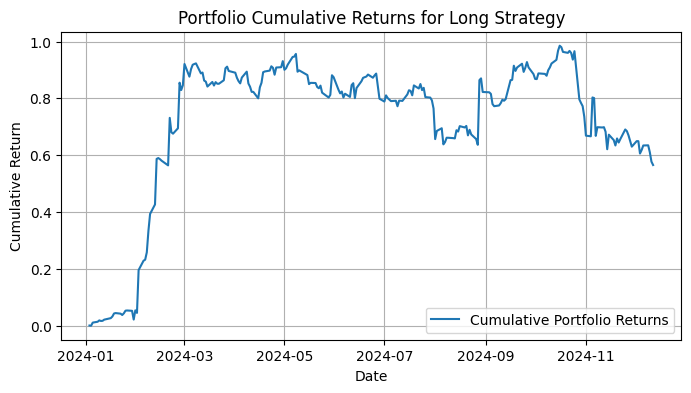

Sharpe Ratio: -3.478, 
Total Return: -75.053%


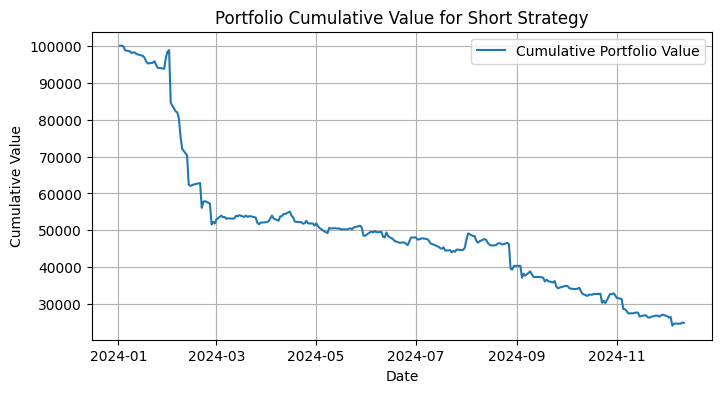

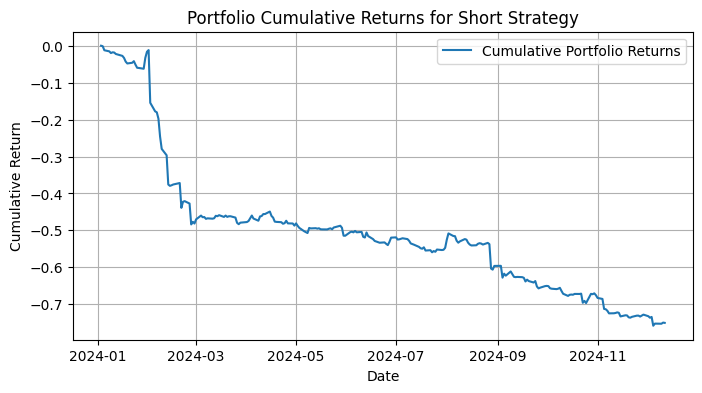

Sharpe Ratio: -3.374, 
Total Return: -33.170%


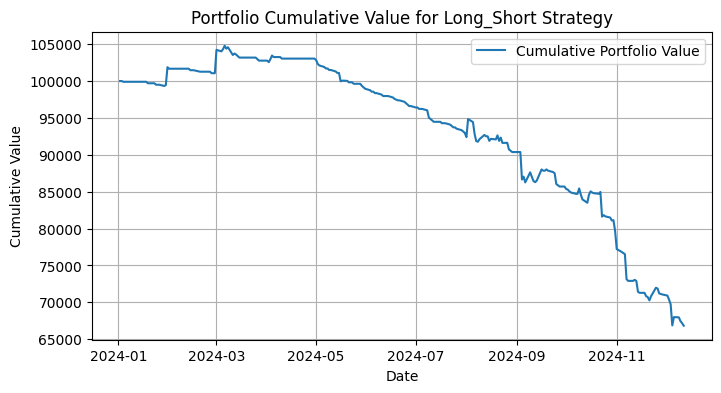

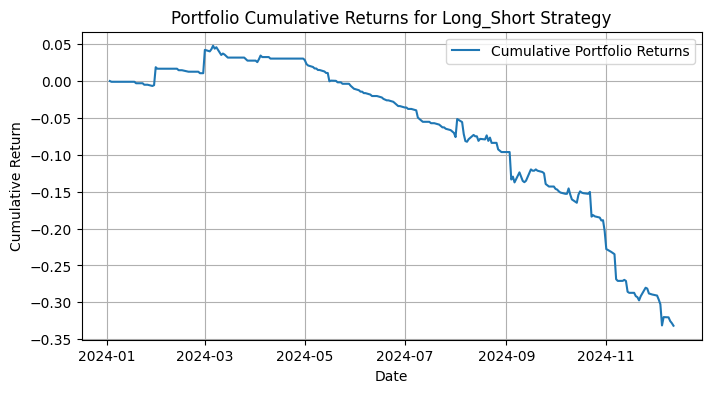

In [32]:
for strat in ['Long','Short', 'Long_Short']:
    fb_portfolio = Portfolio(stocks, strat, long_tickers_dict=fb_stock_dict_long_only, short_tickers_dict=fb_stock_dict_short_only, trading_cost=0.001)
    fb_portfolio.run_backtest()

# Bert

In [33]:
bert = pd.read_csv('./results/test_df_results_bert_filtered.csv')
# bert['company name(s) - cleaned'] = bert['company name(s) - cleaned'].apply(lambda x: x.strip() if isinstance(x, str) else x)

In [35]:
bert = bert.merge(mapping_df, on=['title','date','source'], how='left')
bert_no_missing = bert[bert.Ticker.notna()].copy()
bert_missing = bert[bert.Ticker.isna()].copy()
bert_missing = bert_missing.merge(co_info, how='left', on='company name(s) - cleaned')
bert_missing['Ticker'] = np.where(bert_missing['Symbol'].notna(), bert_missing['Symbol'], bert_missing['Ticker'])
bert_missing.drop(columns='Symbol', inplace=True)

# Updating the non-missing and missing dataframe
bert_no_missing = pd.concat([bert_no_missing, bert_missing[bert_missing['Ticker'].notna()]])
bert_missing = bert_missing[bert_missing['Ticker'].isna()].copy()

# Mapping using ticker info in topic columns
bert_missing['Ticker'] = bert_missing['topic'].apply(lambda x: extract_ticker(str(x)))

# Updating the non-missing and missing dataframe
bert_no_missing = pd.concat([bert_no_missing, bert_missing[bert_missing['Ticker'].notna()]])
bert_missing = bert_missing[bert_missing['Ticker'].isna()].copy()

bert_missing = bert_missing.merge(z[['source', 'Ticker']],on='source', how='left')
bert_missing.drop(columns='Ticker_x', inplace=True)
bert_missing.rename(columns={'Ticker_y':'Ticker'}, inplace=True)

bert_no_missing = pd.concat([bert_no_missing, bert_missing])

In [37]:
b2 = bert_no_missing[['date', 'Ticker','prob_negative']].copy()
b2['date'] = pd.to_datetime(b2['date'])
b2['score'] = 1- b2['prob_negative']
b2.drop(columns='prob_negative', inplace=True)
b2.rename(columns={'Ticker':'ticker'},inplace=True)

b2 = b2[b2['ticker'].isin(sp500_tickers)].copy()

In [38]:
b_stock_dict_long_only = pick_stocks(b2, 'long', 0.2)
# nb_stock_dict_long_only

b_stock_dict_short_only = pick_stocks(b2, 'short', 0.2)
# nb_stock_dict_short_only

Sharpe Ratio: 1.270, 
Total Return: 51.666%


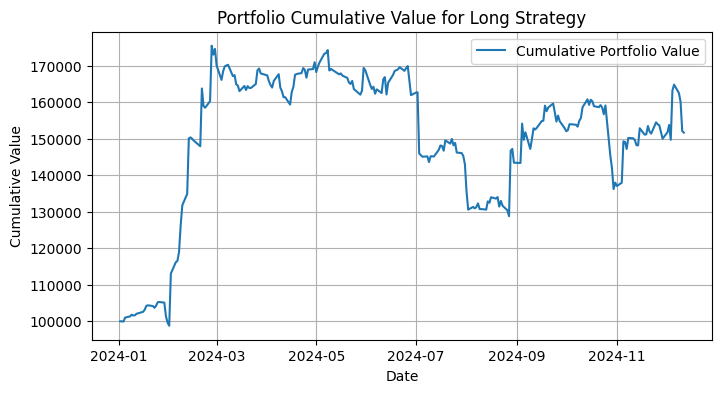

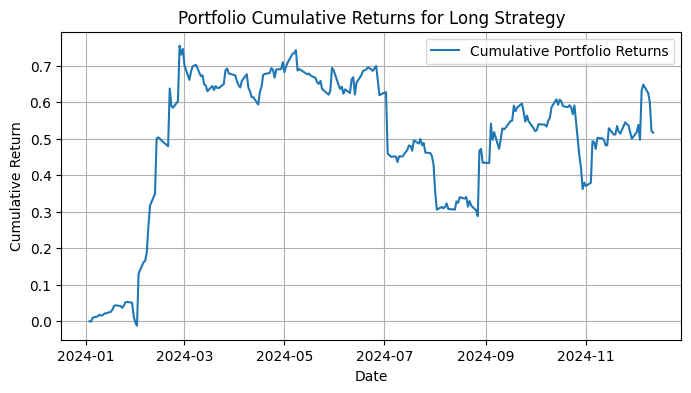

Sharpe Ratio: -3.007, 
Total Return: -69.503%


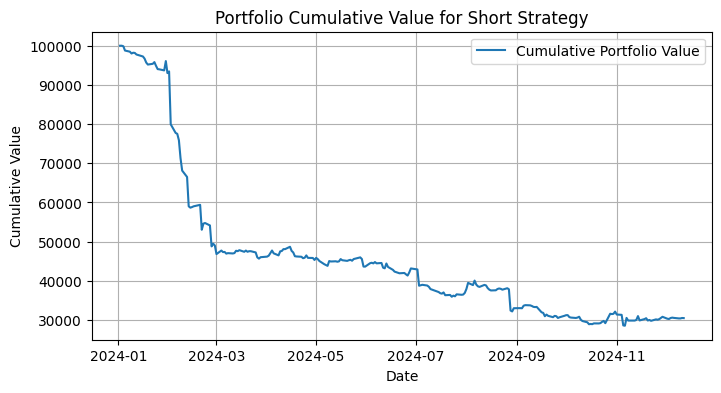

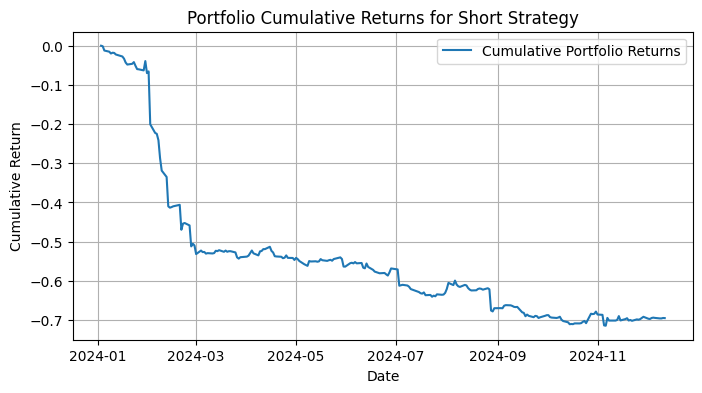

Sharpe Ratio: -2.178, 
Total Return: -27.306%


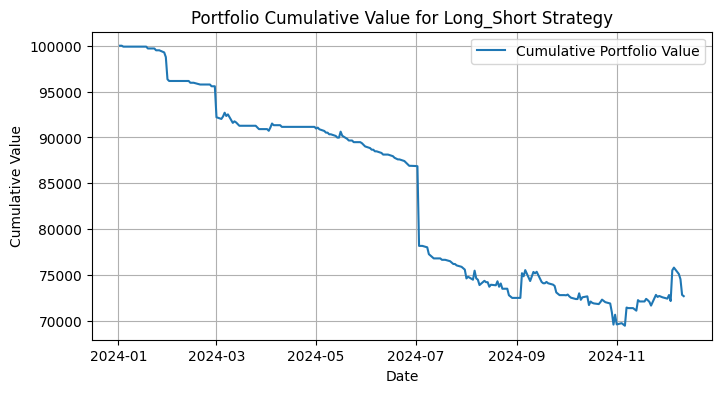

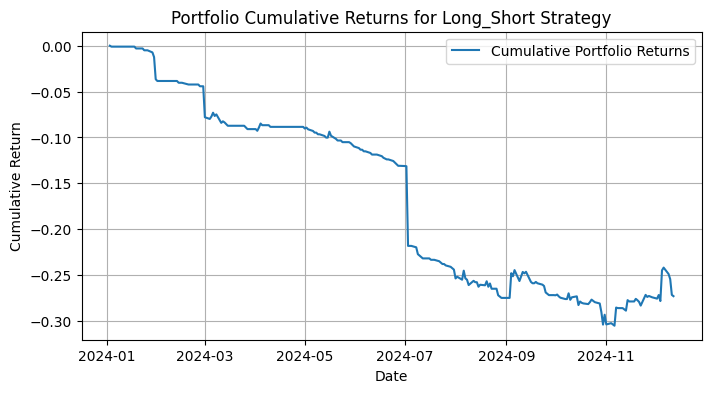

In [39]:
for strat in ['Long','Short', 'Long_Short']:
    b_portfolio = Portfolio(stocks, strat, long_tickers_dict=b_stock_dict_long_only, short_tickers_dict=b_stock_dict_short_only, trading_cost=0.001)
    b_portfolio.run_backtest()

# Overall

         NB       RNN   FinBert      Bert
0  1.424824  1.787093  1.414481  1.269942
         NB       RNN  FinBert      Bert
0  0.587137  0.832046  0.56514  0.516657


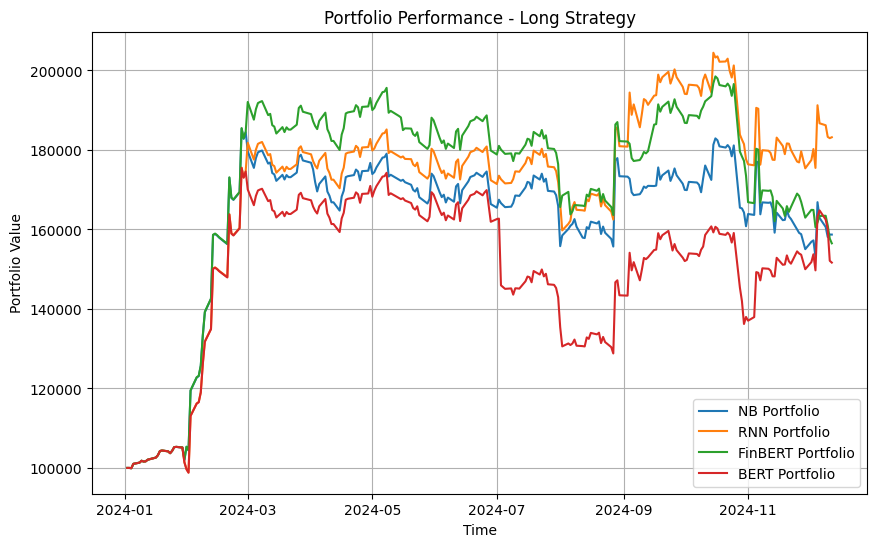

         NB       RNN   FinBert     Bert
0 -3.346893 -2.935882 -3.478159 -3.00724
         NB       RNN   FinBert      Bert
0 -0.726497 -0.670609 -0.750531 -0.695027


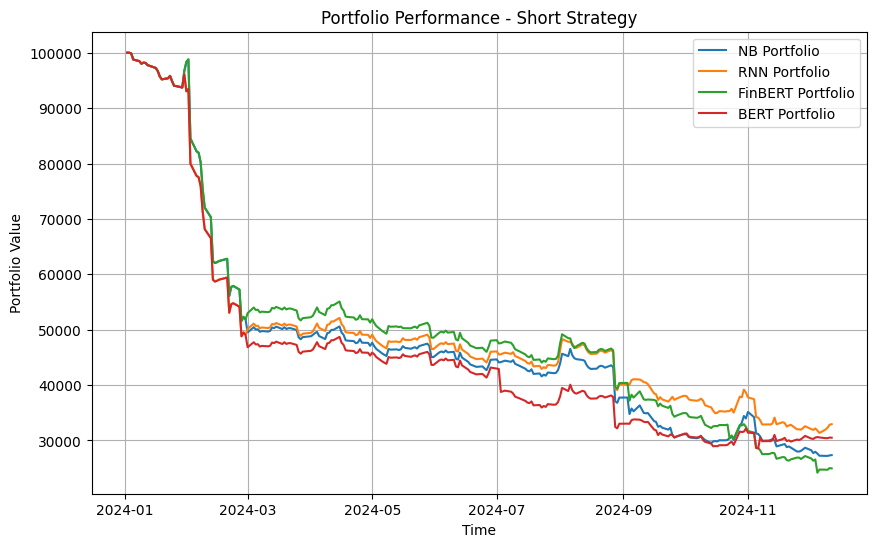

         NB      RNN   FinBert      Bert
0 -2.873883 -1.72656 -3.373729 -2.178213
         NB       RNN   FinBert      Bert
0 -0.296027 -0.169385 -0.331696 -0.273058


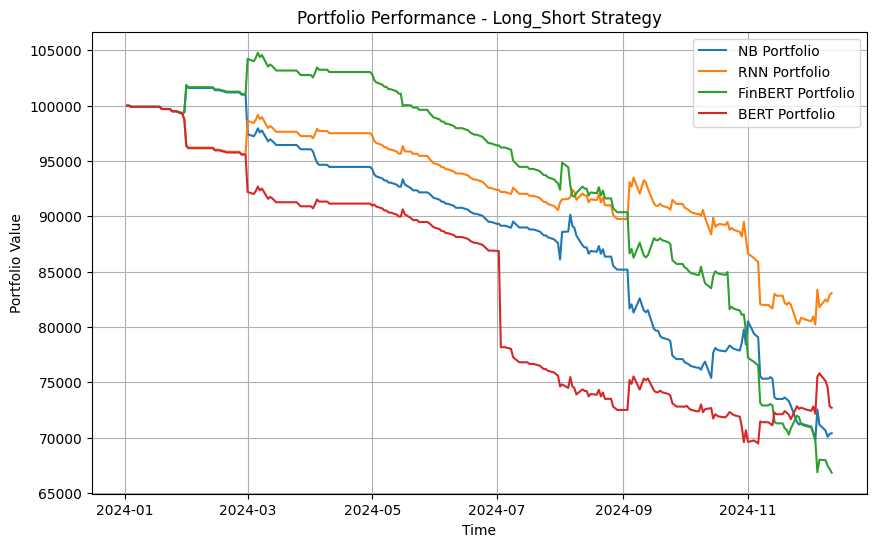

In [51]:
for strat in ['Long', 'Short', 'Long_Short']:
    # Initialize the portfolios
    nb_portfolio = Portfolio(stocks, strat, long_tickers_dict=nb_stock_dict_long_only, short_tickers_dict=nb_stock_dict_short_only, trading_cost=0.001)
    nb_portfolio.calculate_portfolio_returns()

    rnn_portfolio = Portfolio(stocks, strat, long_tickers_dict=rnn_stock_dict_long_only, short_tickers_dict=rnn_stock_dict_short_only, trading_cost=0.001)
    rnn_portfolio.calculate_portfolio_returns()

    fb_portfolio = Portfolio(stocks, strat, long_tickers_dict=fb_stock_dict_long_only, short_tickers_dict=fb_stock_dict_short_only, trading_cost=0.001)
    fb_portfolio.calculate_portfolio_returns()

    b_portfolio = Portfolio(stocks, strat, long_tickers_dict=b_stock_dict_long_only, short_tickers_dict=b_stock_dict_short_only, trading_cost=0.001)
    b_portfolio.calculate_portfolio_returns()

    sharpe_ratio_df = pd.DataFrame(
        {
            'NB':[nb_portfolio.calculate_sharpe_ratio()],
            'RNN': [rnn_portfolio.calculate_sharpe_ratio()],
            'FinBert': [fb_portfolio.calculate_sharpe_ratio()],
            'Bert': [b_portfolio.calculate_sharpe_ratio()]
            })
    
    total_return_df = pd.DataFrame(
    {
        'NB':[nb_portfolio.calculate_total_return()],
        'RNN': [rnn_portfolio.calculate_total_return()],
        'FinBert': fb_portfolio.calculate_total_return(),
        'Bert': [b_portfolio.calculate_total_return()]
        })
    
    print(sharpe_ratio_df)

    print(total_return_df)
    # Plot each strategy's results separately
    plt.figure(figsize=(10, 6))
    plt.plot(nb_portfolio.portfolio_value.set_index('Date'), label='NB Portfolio')
    plt.plot(rnn_portfolio.portfolio_value.set_index('Date'), label='RNN Portfolio')
    plt.plot(fb_portfolio.portfolio_value.set_index('Date'), label='FinBERT Portfolio')
    plt.plot(b_portfolio.portfolio_value.set_index('Date'), label='BERT Portfolio')

    # Add labels, title, and legend
    plt.title(f"Portfolio Performance - {strat} Strategy")
    plt.xlabel("Time")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.grid()
    plt.show()
